In [1]:
!pip install isoweek

In [2]:
!wget 'https://raw.githubusercontent.com/AndrDFg/Homework.-Netology.-Data-Science/05fe52710766aa55997d549cabb35becae0e4abd/13.%20%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%80%D1%8F%D0%B4%D1%8B/%D0%94%D0%97_1_%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%80%D1%8F%D0%B4%D1%8B%2C%20%D0%BE%D0%B1%D1%89%D0%B0%D1%8F%20%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F/time_series6_csv.zip' -O zip_temp.zip


--2025-06-29 12:10:35--  https://raw.githubusercontent.com/AndrDFg/Homework.-Netology.-Data-Science/05fe52710766aa55997d549cabb35becae0e4abd/13.%20%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%80%D1%8F%D0%B4%D1%8B/%D0%94%D0%97_1_%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5%20%D1%80%D1%8F%D0%B4%D1%8B%2C%20%D0%BE%D0%B1%D1%89%D0%B0%D1%8F%20%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F/time_series6_csv.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5687 (5.6K) [application/zip]
Saving to: ‘zip_temp.zip’

zip_temp.zip        100%[===================>]   5.55K  --.-KB/s    in 0s      

2025-06-29 12:10:35 (39.4 MB/s) - ‘zip_temp.zip’ saved [5687/5687]



In [3]:
"""from google.colab import drive
drive.mount('/content/drive')"""

"from google.colab import drive\ndrive.mount('/content/drive')"

In [4]:
import zipfile, re, numpy as np
import datetime, dateutil
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller # Проверка стационарности с помощью теста Дики-Фуллера
from scipy.stats import boxcox                 # Метод для нормализации дисперсии
from sklearn import metrics

In [5]:
#zip_path = '/content/drive/MyDrive/DFD_Учёба/Домашнее Задание/13. Временные ряды/ДЗ_1_Временные ряды общая теория/time_series_6_csv.zip'

In [6]:
with zipfile.ZipFile(file='/content/zip_temp.zip', mode='r') as zip_:
   files_list = [file.filename for file in zip_.filelist]
print('Содержимое zip архива:')
files_list

Содержимое zip архива:


['mean-monthly-air-temperature-deg.csv',
 'monthly-boston-armed-robberies-j.csv',
 'monthly-sales-of-company-x-jan-6.csv',
 'weekly-closings-of-the-dowjones-.csv',
 'daily-total-female-births-in-cal.csv',
 'international-airline-passengers.csv']

In [7]:
with zipfile.ZipFile('/content/zip_temp.zip', mode='r') as data_files:
  data_files.extractall()

In [8]:
mean_monthly_air_temperature_deg = pd.read_csv('mean-monthly-air-temperature-deg.csv') # среднемесячная температура воздуха,град
monthly_boston_armed_robberies = pd.read_csv('monthly-boston-armed-robberies-j.csv')   # ежемесячные вооруженные ограбления в Бостоне
monthly_sales_of_company_x_jan = pd.read_csv('monthly-sales-of-company-x-jan-6.csv')   # ежемесячные продажи компании-x январь
weekly_closings_of_the_dowjones = pd.read_csv('weekly-closings-of-the-dowjones-.csv')  # еженедельные закрытия индекса dowjones
daily_total_female_births_in_cal = pd.read_csv('daily-total-female-births-in-cal.csv') # ежедневное общее число рождений женщин в Калифорнии
international_airline_passengers = pd.read_csv('international-airline-passengers.csv') # международные авиакомпании пассажиры

## **Графики полученных данных**

In [9]:
# Формирую словарик, где ключи - названия датасетов, значения: весь датафрейм, данные и название 1 столбца для оси x, данные и название 2 столбца для оси y
dict_datasets = {'mean_monthly_air_temperature_deg': (mean_monthly_air_temperature_deg, mean_monthly_air_temperature_deg.columns[0], mean_monthly_air_temperature_deg.columns[1]),
 'monthly_boston_armed_robberies': (monthly_boston_armed_robberies, monthly_boston_armed_robberies.columns[0], monthly_boston_armed_robberies.columns[1]),
 'monthly_sales_of_company_x_jan': (monthly_sales_of_company_x_jan, monthly_sales_of_company_x_jan.columns[0], monthly_sales_of_company_x_jan.columns[1]),
 'weekly_closings_of_the_dowjones': (weekly_closings_of_the_dowjones, weekly_closings_of_the_dowjones.columns[0], weekly_closings_of_the_dowjones.columns[1]),
 'daily_total_female_births_in_cal': (daily_total_female_births_in_cal, daily_total_female_births_in_cal.columns[0], daily_total_female_births_in_cal.columns[1]),
 'international_airline_passengers': (international_airline_passengers, international_airline_passengers.columns[0], international_airline_passengers.columns[1])}

In [10]:
def series_index_date(df, label_date, start_date, freq):
  """Функция которое формирует Series c индексом типа DatetimeIndex"""
  date_index = pd.date_range(start=start_date,  periods=df.shape[0], freq=freq)
  df_check_date = df.set_index(date_index)
  df_check_date.drop(labels=label_date, axis=1, inplace=True)
  return df_check_date.iloc[:, 0]

##SMA

In [11]:
# Функция для построения прогноза по модели MA
def ma_forecast_3(series, window_size, forecast_horizon, freq='ME'):
    """
    Функция которая разделяет временной ряд на train and test.
    Строит прогноз на основе модели скользящего среднего (MA)
    Parameters:
    -----------
    series: Series-         Исходный временной ряд
    window_size: int-       Размер окна для расчета скользящего среднего
    forecast_horizon : int- Горизонт прогнозирования

    Returns: series (исходная серия), forecast (серия с прогнозами), new_series(series+forecast), ma(int: values)
    """
    # Создаем копию исходного ряда
    new_series = series.copy()
    # Разделение данных временного ряда
    train_series = new_series.iloc[: -forecast_horizon]

    # Рассчитывает скользящее среднее для исходных данных до разделения серии на train and test.
    ma_series = series.rolling(window=window_size).mean()
    # Рассчитывает скользящее среднее для train
    ma_train = train_series.rolling(window=window_size).mean()

    # Добавляем прогнозные значения
    for i in range(forecast_horizon):
        # Последнее окно данных
        last_window = train_series.tail(window_size)
        # среднее значение окна
        next_value = last_window.mean()
        # формируем серию со средним значением окна
        window_series = pd.Series(data=next_value)
        train_series = pd.concat([train_series, window_series])

    index_series = pd.date_range(start=series.index[0], periods=len(train_series), freq=freq)
    train_series = pd.Series(train_series.values, index=index_series)
    # Возвращает прогнозные значения
    predict = train_series.tail(forecast_horizon)
    # Возвращает истинные значения
    test_series = new_series.iloc[-forecast_horizon :]

    return series, train_series, predict, test_series, ma_series, ma_train


In [12]:
def ma_chart(series, window_size, forecast_horizon):
  """ функция построения графика прогноза """
  series, train_series, predict, test_series, ma_series, ma_train = ma_forecast_3(series, window_size, forecast_horizon)
  sns.set_style('darkgrid')
  plt.figure(figsize=(22, 6))
  sns.lineplot(data=series, label='Исходные данные о среднемесячной температуры воздуха')
  sns.lineplot(data=ma_train, label=f'Скользящее среднее, окно - ({window_size})', color='red')
  sns.lineplot(data=predict, label=f'Скользящее среднее (предсказанные значения), горизонт предсказания - {forecast_horizon}')
  plt.grid(True)
  plt.tick_params(grid_alpha=0.1, grid_color='b')
  mae = metrics.mean_absolute_error(test_series, predict)
  rmse = metrics.root_mean_squared_error(test_series, predict)
  print (f'MAE:  {np.round(mae, 5)}\nRMSE: {np.round(rmse, 5)}')

In [13]:
# СТАЦИОНАРНЫЙ РЯД
ma_mean_monthly_air_temperature_deg = series_index_date(dict_datasets['mean_monthly_air_temperature_deg'][0], 'Month', '1959', 'ME')
ma_mean_monthly_air_temperature_deg.tail(5)

,Deg
1978-08-31,61.8
1978-09-30,58.2
1978-10-31,46.7
1978-11-30,46.6
1978-12-31,37.8


MAE:  7.81499
RMSE: 8.86464


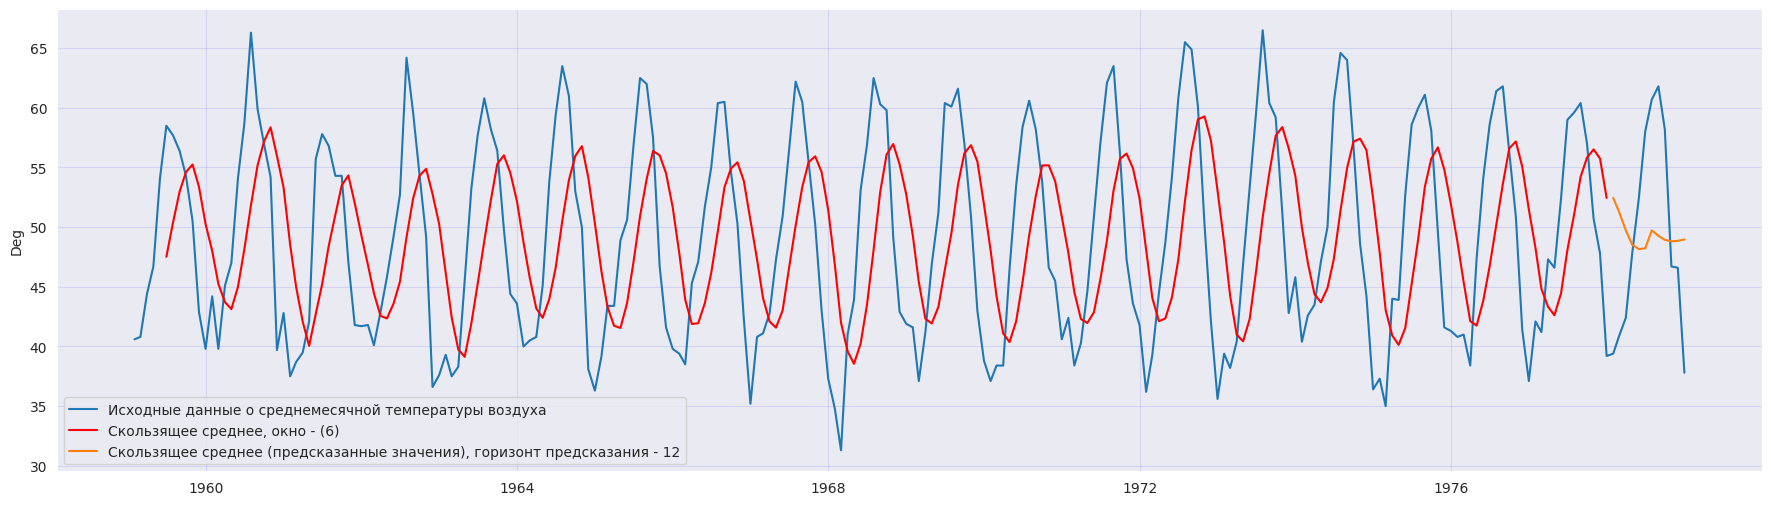

In [14]:
ma_chart(series=ma_mean_monthly_air_temperature_deg, window_size=6, forecast_horizon=12)

In [15]:
# НЕСТАЦИОНАРНЫЙ РЯД
ma_monthly_sales_of_company_x_jan = series_index_date(df=dict_datasets['monthly_sales_of_company_x_jan'][0], label_date='Month', start_date='1965', freq='ME')
ma_monthly_sales_of_company_x_jan.tail()

,Count
1971-01-31,628
1971-02-28,308
1971-03-31,324
1971-04-30,248
1971-05-31,272


MAE:  292.64905
RMSE: 341.57437


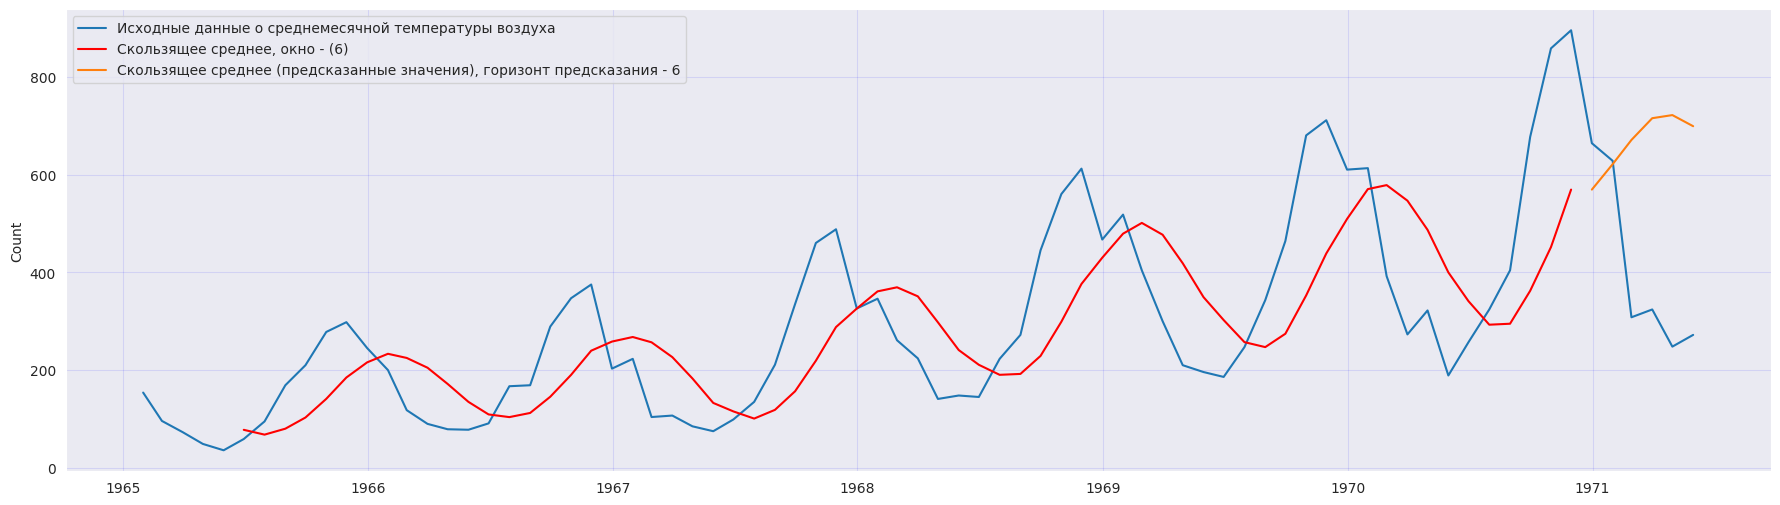

In [16]:
ma_chart(series=ma_monthly_sales_of_company_x_jan, window_size=6, forecast_horizon=6)

## EMA

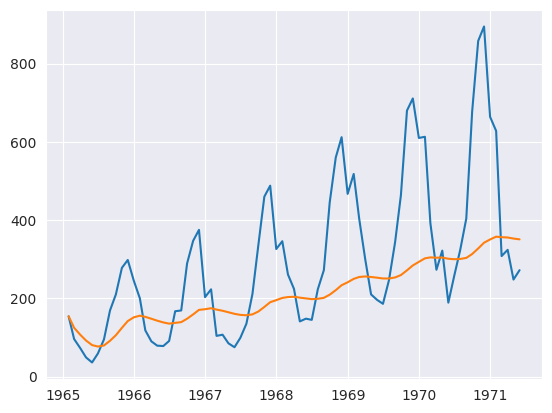

In [17]:
# alpha = 2/(span+1). (если 10, то результат ≈ 0.182) - это вес последнего значения, а вес предыдущего значения будет 0,818
plt.plot(ma_monthly_sales_of_company_x_jan)
plt.plot(ma_monthly_sales_of_company_x_jan.ewm(50).mean());